In [2]:
import pandas as pd
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import heapq

import string
import spacy
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kasih\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kasih\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kasih\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import gensim
import pickle
from scipy.sparse import save_npz
from gensim.models.phrases import Phraser, Phrases
from gensim.models.word2vec import Word2Vec

Load Data

In [4]:
csv_file_path = "C:\\Users\\kasih\\OneDrive\\Acer Desktop\\nlp_project\\data\\train-00000-of-00001.parquet"
df = pd.read_parquet(csv_file_path)
display(df.head())

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [5]:
corpus=df['text'].tolist()
print(f"Columns: {df.columns.tolist()}")
print("Data Types:")
print(df.dtypes)

print(f"\nCorpus loaded: {len(corpus)} documents")
print(f"\nFirst document ({len(corpus[0].split())} words):\n{corpus[0][:150]}...")

Columns: ['text', 'label']
Data Types:
text       str
label    int64
dtype: object

Corpus loaded: 416809 documents

First document (26 words):
i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here...


Data Exploration

In [6]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "No missing values found.")

Missing Values:
No missing values found.


In [7]:
label_col = 'label'

print(f"Class Distribution ('{label_col}'):")
class_counts = df[label_col].value_counts()
class_pct    = df[label_col].value_counts(normalize=True) * 100

class_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})
print(class_df)

Class Distribution ('label'):
        Count  Percentage (%)
label                        
1      141067           33.84
0      121187           29.07
3       57317           13.75
4       47712           11.45
2       34554            8.29
5       14972            3.59


In [8]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("Imbalance detected.")
else:
    print("Classes are relatively balanced.")

Imbalance Ratio (max/min): 9.42
Imbalance detected.


In [9]:
# Check class distribution before balancing
print("Before balancing:")
print(df['label'].value_counts())

# Cap each class at 8000 samples
df = (
    pd.concat([
        group.sample(n=min(len(group), 8000), random_state=42)
        for _, group in df.groupby('label')
    ])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Shuffle so rows aren't grouped by label
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df['label'].value_counts())

Before balancing:
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

After balancing:
label
4    8000
1    8000
5    8000
0    8000
3    8000
2    8000
Name: count, dtype: int64


In [10]:
df['text_length']     = df['text'].apply(lambda x: len(x))
df['word_count']      = df['text'].apply(lambda x: len(x.split()))

print("Text Length Stats (characters):")
print(df['text_length'].describe().round(2))

print(f"\nWord Count Stats:")
print(df['word_count'].describe().round(2))

Text Length Stats (characters):
count    48000.00
mean        98.16
std         56.34
min          4.00
25%         55.00
50%         87.00
75%        129.00
max        525.00
Name: text_length, dtype: float64

Word Count Stats:
count    48000.00
mean        19.43
std         11.10
min          1.00
25%         11.00
50%         17.00
75%         26.00
max        100.00
Name: word_count, dtype: float64


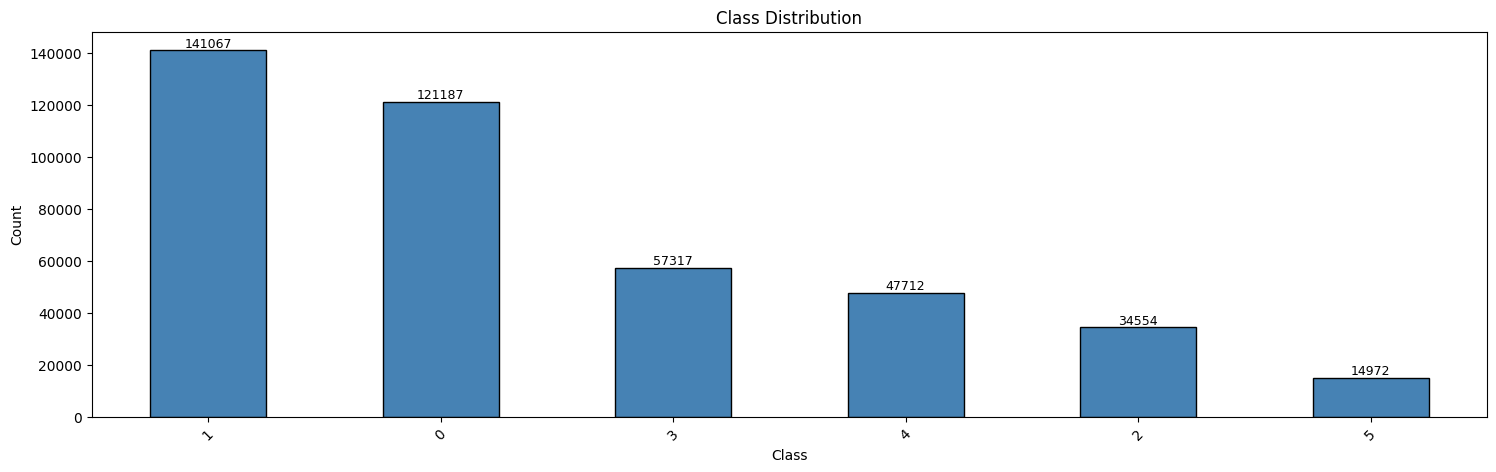

In [11]:
# Class distribution bar chart

fig, axes = plt.subplots(1, 1, figsize=(18, 5))
class_counts.plot(kind='bar', ax=axes, color='steelblue', edgecolor='black')
axes.set_title('Class Distribution')
axes.set_xlabel('Class')
axes.set_ylabel('Count')
axes.tick_params(axis='x', rotation=45)
for bar, val in zip(axes.patches, class_counts):
    axes.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9)

In [12]:
df.to_csv('../data/balanced_data.csv', index=False)

Text Preprocessing

In [13]:
# convert to lowercase and tokenize
lower_corpus = [i.lower() for i in corpus]
stop_words = set(stopwords.words('english'))
words = [word_tokenize(i) for i in lower_corpus]

#remove stopwords and special chars per document then lemmatize
lem = WordNetLemmatizer()
cleaned = []
cleaned_words=[]
for sentence in words:
  cleaned_tokens=[]
  for token in sentence:
        cleaned_token = token.strip(string.punctuation)
        if cleaned_token and cleaned_token not in stop_words and cleaned_token.isalpha():
            lemmatized = lem.lemmatize(cleaned_token)
            cleaned_tokens.append(lemmatized)
  cleaned.append(" ".join(cleaned_tokens))
  cleaned_words.append(cleaned_tokens)

cleaned_words : use for w2v model





cleaned : use for tfidf

Feature Extraction W2V SkipGram

In [14]:
with open('../data/cleaned_words.pkl', 'wb') as f:
    pickle.dump(cleaned_words, f)

In [15]:
with open('../data/cleaned.pkl', 'wb') as f:
    pickle.dump(cleaned, f)

In [19]:
skipgram = Word2Vec(
    sentences=cleaned_words,
    vector_size=100,
    sg=1,
    window=10,
    epochs=10,
    min_count=10,
    workers=4,
    seed=42
)
skipgram.save("../models/word2vec.model")

print(f"Skip-gram vocab: {len(skipgram.wv)}")
print(f"Successfully saved word2vec model.")

Skip-gram vocab: 13524
Successfully saved word2vec model.


Feature Extraction Tfidf

In [22]:
tfidf=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    norm='l2')
tfidf_matrix=tfidf.fit_transform((cleaned))

In [23]:
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

save_npz('../data/tfidf_vectors.npz', tfidf_matrix)

print(f"TFIDF vocab: {len(tfidf.get_feature_names_out())}")
print(f"Successfully saved vectorizer object in.")
print(f"Successfully saved tfidf matrix.")

TFIDF vocab: 5000
Successfully saved vectorizer object in.
Successfully saved tfidf matrix.


tfidf selects only the top 500 most important terms by score.
w2v's 13,524 reflects the true number of distinct words 